## **TELECOM CUSTOMER CHURN PREDICTION AND ANALYSIS**

### **PROBLEM STATEMENT**

Customer churn refers to customers who stop using a company's services.
The objective of this project is to predict whether a telecom customer will churn or not using historical customer data.
By identifying customers likely to churn, companies can take preventive actions such as offering discounts or improving services.

### **DATASET DESCRIPTION**

The dataset contains information about telecom customers, including demographic details, account information, and service usage.
Each row represents a customer and each column represents a feature describing that customer.

##### **Key Features**

- **gender** : Customer gender
- **SeniorCitizen** : Whether the customer is a senior citizen
- **tenure** : Number of months the customer has stayed with the company
- **MonthlyCharges** : Monthly service charges
- **TotalCharges** : Total amount charged to the customer
- **Contract** : Contract type
- **InternetService** : Type of internet service used
- **PaymentMethod** : Payment method used by the customer
- **Churn** : Whether the customer left the company

##### **Target Variable**
**Churn**

- Yes → Customer left the service
- No → Customer stayed with the company

### **INITIAL EDA**

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [212]:
df = pd.read_csv("../data/telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [213]:
df.shape

(7043, 21)

In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [215]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [216]:
#Numerical variables
df.select_dtypes(include=['int64','float64']).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [217]:
#Categorical variables
df.select_dtypes(include='object').columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [218]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [219]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

#### **DISTRIBUTION OF CUSTOMER TENURE**

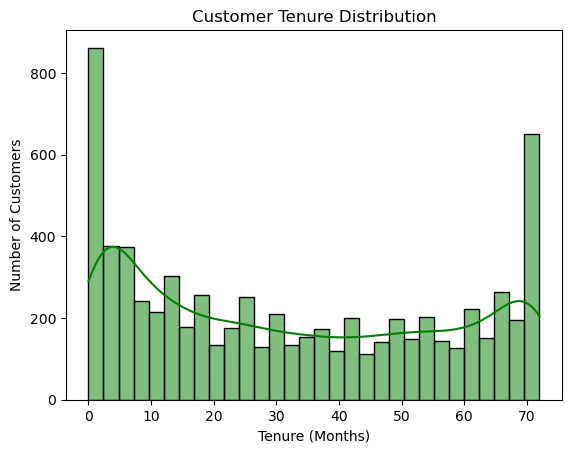

In [220]:
sns.histplot(df['tenure'], bins=30 ,kde = True, color = 'green')
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

**INSIGHTS**

- A large number of customers have very low tenure (0–5 months), indicating many new customers.
- Another noticeable concentration exists around high tenure values (~70 months), representing long-term loyal customers.
- The distribution suggests that customers are either very new or very long-term, with fewer customers in the middle tenure range.

#### **TENURE VS MONTHLY CHARGES**

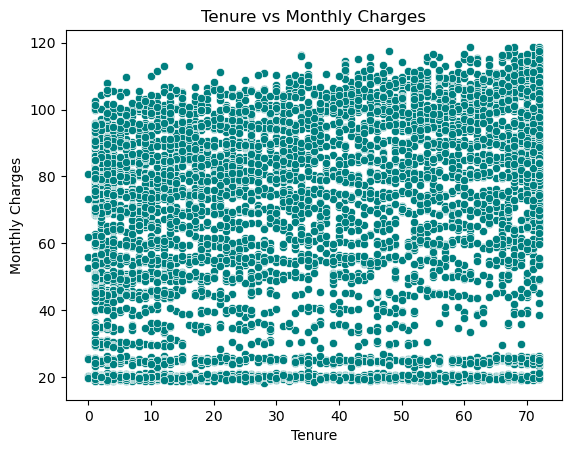

In [221]:
sns.scatterplot(x='tenure', y='MonthlyCharges',color = 'teal', data=df)
plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

**INSIGHTS**

- There is no strong linear relationship between tenure and monthly charges.
- Customers with both short and long tenure pay a wide range of monthly charges.
- Pricing appears to depend more on service packages rather than customer tenure

#### **CORRELATION HEATMAP**

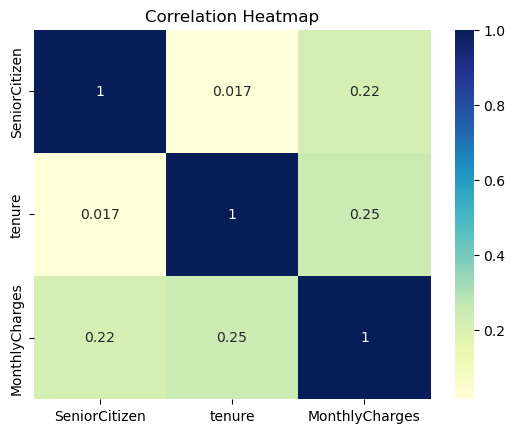

In [222]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()

**INSIGHTS**

- The correlation values among the numerical variables are weak, indicating no strong linear relationships.
- SeniorCitizen shows almost no correlation with tenure, indicating age group does not strongly influence customer retention duration.
- Since correlations are weak, churn behavior likely depends on multiple variables rather than a single factor.

#### **CUSTOMER CHURN BY CONTRACT TYPE**

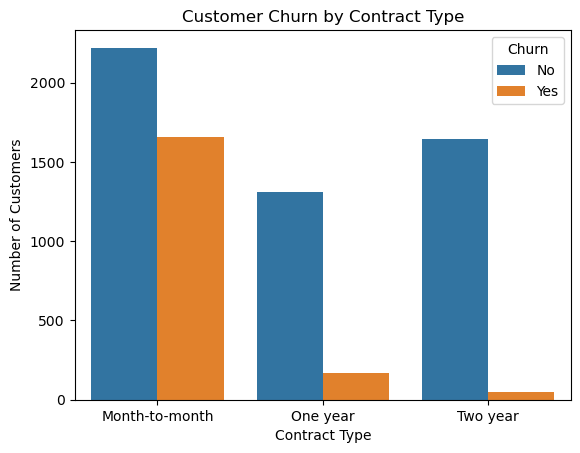

In [223]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

**INSIGHTS**

- Customers with month-to-month contracts show the highest churn rates.
- Customers with one-year and two-year contracts exhibit significantly lower churn.
- Long-term contracts encourage customer commitment and retention.

#### **CHURN VS TENURE**

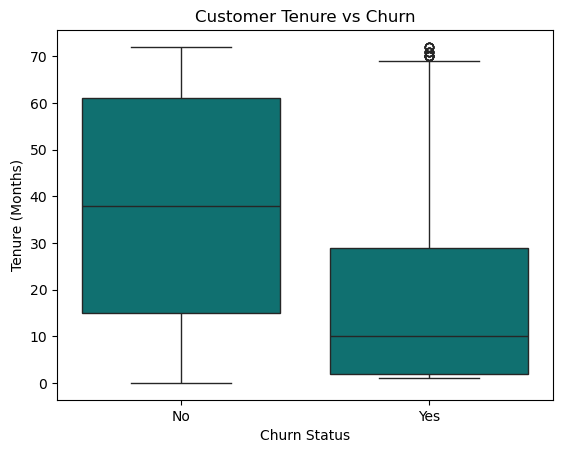

In [224]:
sns.boxplot(x='Churn', y='tenure', data=df, color = 'teal')
plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")
plt.show()

**INSIGHTS**

- Customers who churn generally have much lower tenure compared to customers who stay.
- Most churn occurs within the early months of the customer lifecycle.
- Customers with long tenure rarely churn, indicating strong loyalty.

#### **MONTHLY CHARGES DISTIBUTION**

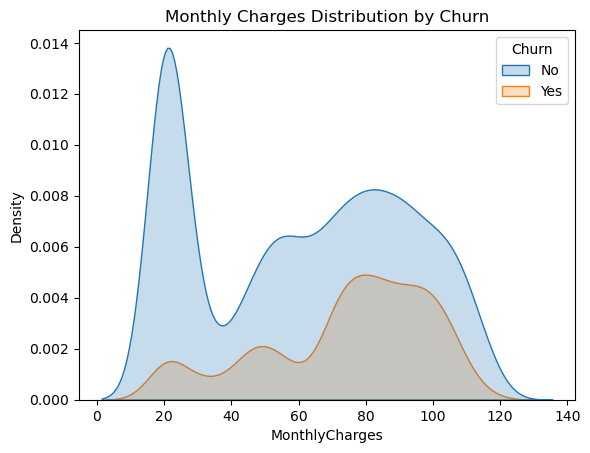

In [225]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

**INSIGHTS**

- Customers who churn tend to have higher monthly charges, especially in the range of $70–$100, indicating that higher pricing may contribute to churn.
- Customers with lower monthly charges (~$20–$30) show very low churn, suggesting that basic or low-cost plans retain customers better.
- The overlap between the two distributions indicates that monthly charges alone do not fully explain churn, but they still play an important role when combined with other factors like tenure and contract type.

#### **CHURN BY PAYMENT METHOD**

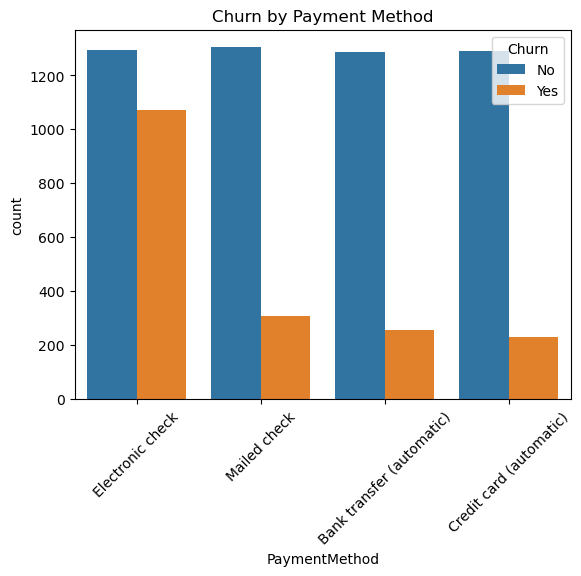

In [226]:
sns.countplot(x='PaymentMethod',hue = 'Churn', data = df)
plt.xticks(rotation = 45)
plt.title('Churn by Payment Method')
plt.show()

**INSIGHTS**

- Customers using Electronic Check have the highest churn, indicating higher risk among this payment group.
- Encouraging customers to use automatic payment methods may help reduce churn.

### **DATA CLEANING & PREPROCESSING**

#### Fixing Datatypes

In [227]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [228]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#### Handling Missing Values

In [229]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [230]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

#### Handling Duplicate Values

In [231]:
df.duplicated().sum()

np.int64(0)

#### Removing Unwanted Columns

In [232]:
df.drop(['customerID','Partner','Dependents'],axis = 1, inplace = True)

In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   tenure            7043 non-null   int64  
 3   PhoneService      7043 non-null   object 
 4   MultipleLines     7043 non-null   object 
 5   InternetService   7043 non-null   object 
 6   OnlineSecurity    7043 non-null   object 
 7   OnlineBackup      7043 non-null   object 
 8   DeviceProtection  7043 non-null   object 
 9   TechSupport       7043 non-null   object 
 10  StreamingTV       7043 non-null   object 
 11  StreamingMovies   7043 non-null   object 
 12  Contract          7043 non-null   object 
 13  PaperlessBilling  7043 non-null   object 
 14  PaymentMethod     7043 non-null   object 
 15  MonthlyCharges    7043 non-null   float64
 16  TotalCharges      7043 non-null   float64


#### Checking Value Consistency

In [234]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [235]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [236]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

#### Encode Categorical Variable 

In [237]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [238]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [239]:
df = pd.get_dummies(df, drop_first = True).astype(int)

In [240]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,0,1,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,1,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0


In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   SeniorCitizen                          7043 non-null   int64
 1   tenure                                 7043 non-null   int64
 2   MonthlyCharges                         7043 non-null   int64
 3   TotalCharges                           7043 non-null   int64
 4   Churn                                  7043 non-null   int64
 5   gender_Male                            7043 non-null   int64
 6   PhoneService_Yes                       7043 non-null   int64
 7   MultipleLines_No phone service         7043 non-null   int64
 8   MultipleLines_Yes                      7043 non-null   int64
 9   InternetService_Fiber optic            7043 non-null   int64
 10  InternetService_No                     7043 non-null   int64
 11  OnlineSecurity_No internet ser

In [242]:
df.shape

(7043, 29)

### Issues Found in the Dataset

During the initial inspection of the dataset, a few issues were identified:

* The **TotalCharges** column was stored as an `object` datatype instead of a numerical datatype.
* Some entries in **TotalCharges** contained **missing or blank values**, which resulted in `NaN` values after conversion.
* The dataset contained a **customerID column**, which is only an identifier and does not contribute to predictive modeling.
* Several variables were **categorical**, which cannot be directly used by machine learning algorithms.

### Cleaning Decisions Made

To address the issues identified in the dataset, the following steps were performed:

* The **TotalCharges** column was converted from `object` to a numeric datatype using `pd.to_numeric()`.
* Missing values in **TotalCharges** were filled using the **median value** of the column to maintain the distribution of the data.
* The **customerID** column was removed since it does not provide useful information for prediction.
* The **Churn** column was encoded into binary values (`Yes → 1`, `No → 0`) since it is the target variable.
* Remaining categorical variables were converted into numerical form using **One-Hot Encoding**.

### Assumptions Taken During Preprocessing

The following assumptions were made while cleaning the dataset:

* Missing values in **TotalCharges** were assumed to be minimal and were replaced using the **median**, which is robust to outliers.
* The **customerID** column was assumed to have no predictive value and was therefore removed.
* One-hot encoding was applied to categorical variables assuming that there is **no ordinal relationship between categories**.
* The parameter `drop_first=True` was used during encoding to avoid **multicollinearity** in the model.


### **FEATURE ENGINEERING**

In [243]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [244]:
df['TenureGroup'] = pd.cut(df['tenure'],
                           bins = [0,12,24,48,72],
                           labels = ['0-1 year','1-2 years', '2-4 years',  '4-6 years'])

In [245]:
df = pd.get_dummies(df, columns = ['TenureGroup'], drop_first = True)

In [246]:
service_cols = [
'OnlineSecurity_Yes',
'OnlineBackup_Yes',
'DeviceProtection_Yes',
'TechSupport_Yes',
'StreamingTV_Yes',
'StreamingMovies_Yes'
]
df['TotalServices'] = df[service_cols].sum(axis = 1)

### **MODELING** 

In [247]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,TenureGroup_1-2 years,TenureGroup_2-4 years,TenureGroup_4-6 years,TotalServices
0,0,1,29,29,0,0,0,1,0,0,...,0,1,0,1,0,14.500000,False,False,False,1
1,0,34,56,1889,0,1,1,0,0,0,...,0,0,0,0,1,53.971429,False,True,False,2
2,0,2,53,108,1,1,1,0,0,0,...,0,1,0,0,1,36.000000,False,False,False,2
3,0,45,42,1840,0,1,0,1,0,0,...,0,0,0,0,0,40.000000,False,True,False,3
4,0,2,70,151,1,0,1,0,0,1,...,0,1,0,1,0,50.333333,False,False,False,0


In [248]:
X = df.drop('Churn',axis = 1)
y = df['Churn']

In [249]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

In [250]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [251]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [252]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

### **MODEL EVALUATION**

In [253]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8090844570617459


In [254]:
from sklearn.metrics import precision_score,recall_score

precision = precision_score(y_test,y_pred)
recall = recall_score(y_test, y_pred)
print("Precision :", precision)
print("Recall :", recall)

Precision : 0.6733333333333333
Recall : 0.5415549597855228


In [255]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[938  98]
 [171 202]]


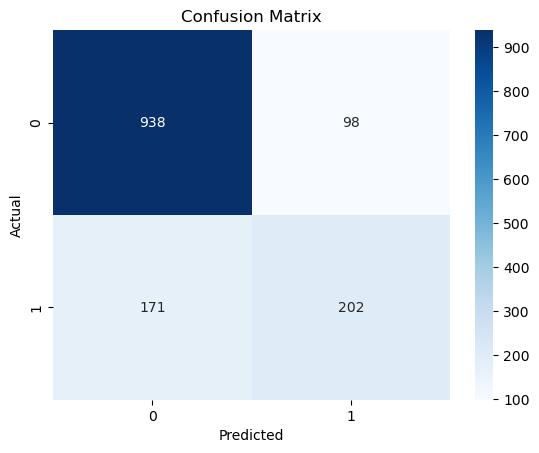

In [256]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

- 938 → Correctly predicted customers who stayed (True Negatives)
- 202 → Correctly predicted customers who churned (True Positives)
- 98 → Predicted churn but actually stayed (False Positives)
- 171 → Predicted stay but actually churned (False Negatives)

## Model Choice

For this project, **Logistic Regression** was chosen as the primary model because the objective is to predict whether a customer will churn or not, which is a **binary classification problem**.

Logistic Regression is a widely used classification algorithm that estimates the probability of a categorical outcome. It models the relationship between the independent variables (customer features such as tenure, contract type, and monthly charges) and the target variable (Churn).

This model was selected because:

* It is simple and interpretable.
* It performs well for binary classification tasks.
* It provides probability estimates for churn prediction.

These characteristics make Logistic Regression suitable for understanding the factors that influence customer churn.

---

## Evaluation Metrics

After training the model, several evaluation metrics were used to measure its performance.

**Accuracy**

Accuracy measures the overall proportion of correctly predicted instances.
It indicates how often the model correctly predicts whether a customer will churn or stay.

**Precision**

Precision measures how many predicted churn cases were actually churned customers.
This metric is important when we want to minimize incorrectly labeling loyal customers as churners.

**Recall**

Recall measures how many actual churn customers were correctly identified by the model.
This is important in churn prediction because companies want to detect as many at-risk customers as possible.

**Confusion Matrix**

The confusion matrix provides a detailed breakdown of predictions, showing the number of correct and incorrect predictions for both churn and non-churn cases.

---

## Interpretation of Results

The evaluation results indicate that the Logistic Regression model can reasonably predict customer churn based on the available features.

From the model evaluation:

* The model achieved a good accuracy score, indicating that it correctly classifies most customers.
* Precision and recall provide insight into how well the model identifies customers likely to churn.
* The confusion matrix helps understand the types of errors made by the model, such as predicting churn for customers who actually stayed or failing to detect customers who eventually churned.

Overall, the results demonstrate that machine learning can effectively identify customers at risk of leaving. These predictions can help companies take proactive actions such as offering promotions, improving customer support, or introducing loyalty programs to retain customers.


## Key Insights

- Customers with month-to-month contracts show the highest churn rate compared to long-term contracts.
- Customers with short tenure are more likely to churn, indicating that the early stage of the customer lifecycle is critical.
- Higher monthly charges are associated with higher churn, suggesting pricing may influence customer retention.
- Customers using electronic check payment methods tend to churn more frequently than those using automatic payment options.

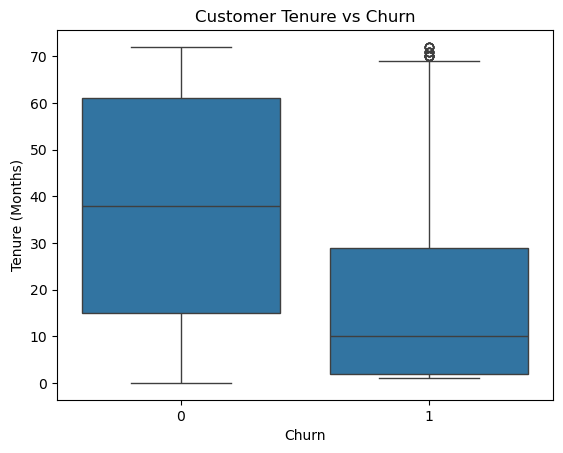

In [257]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

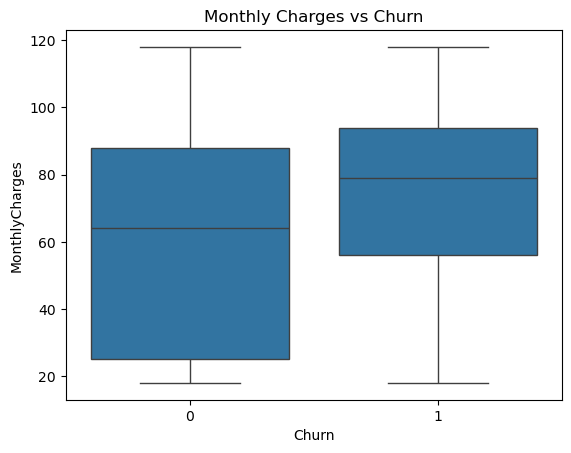

In [258]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

#### **Service Usage Reduces Churn Risk**

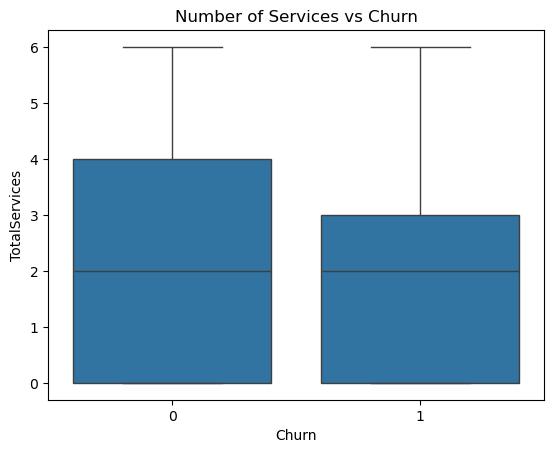

In [259]:
sns.boxplot(x='Churn', y='TotalServices', data=df)
plt.title("Number of Services vs Churn")
plt.show()

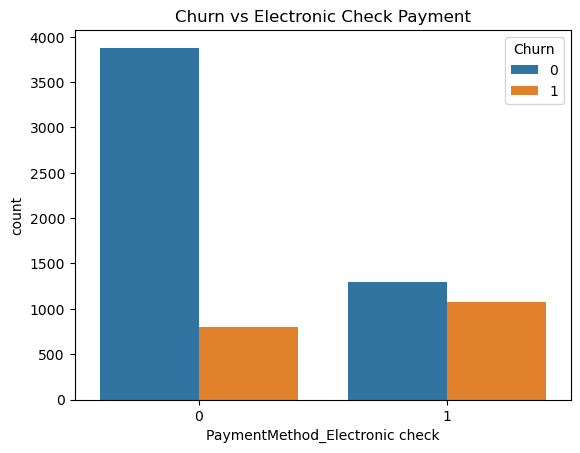

In [260]:
sns.countplot(x='PaymentMethod_Electronic check', hue='Churn', data=df)
plt.title("Churn vs Electronic Check Payment")
plt.show()

### **RECOMMENDATIONS**

- Offer long-term contracts
- Provide better customer support
- Give discounts for high monthly charges
- Encourage customers to subscribe to more services

### **CONCLUSION**


This project analyzed telecom customer data to understand the factors influencing customer churn and to build a predictive model. After cleaning and preprocessing the dataset, feature engineering was performed to capture important customer behavior patterns.

A Logistic Regression model was trained and evaluated using classification metrics such as accuracy, precision, recall, and confusion matrix. The analysis showed that factors like **contract type, customer tenure, monthly charges, and number of services used** significantly influence churn behavior.

Overall, the results demonstrate that machine learning can help companies identify customers at risk of leaving and support strategies to improve customer retention.


### **LIMITATIONS**

- The dataset represents a single telecom provider, which may limit generalization.
- Logistic Regression assumes a linear relationship between features and the log-odds of churn.
- Some external factors influencing churn (customer satisfaction, competitor offers) are not included in the dataset.
- Feature engineering was limited to the available variables

### **POSSIBLE IMPROVEMENTS**

- Testing more advanced models such as Random Forest or Gradient Boosting.
- Performing hyperparameter tuning to optimize model performance.
- Using feature importance analysis to identify the most influential variables.
- Incorporating additional customer behavior data such as service usage frequency or customer support interactions.